<a href="https://colab.research.google.com/github/andyotani/Machine-learning_26-27/blob/main/JS05/Tugas_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUGAS LAB 1

1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.



In [26]:
# Import Library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [27]:
#Load Dataset
data = pd.read_csv("voice.csv")
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [29]:
# Memisahkan fitur dan label
X = data.drop("label", axis=1)
y = data["label"]

In [30]:
# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [31]:
# Standardisasi fitur
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
# Membuat model KNN
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [37]:
# Evaluasi model
y_pred = knn.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Accuracy: 0.9737118822292324

Confusion Matrix:
[[462  14]
 [ 11 464]]

Classification Report:
              precision    recall  f1-score   support

      female       0.98      0.97      0.97       476
        male       0.97      0.98      0.97       475

    accuracy                           0.97       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.97      0.97      0.97       951



2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?



In [40]:
# Seleksi fitur
from sklearn.feature_selection import SelectKBest, f_classif

In [41]:
# Percobaan jumlah fitur:
hasil = []

for jumlah_fitur in range(2,21):

    selector = SelectKBest(
        score_func=f_classif,
        k=jumlah_fitur
    )

    X_train_selected = selector.fit_transform(
        X_train,
        y_train
    )

    X_test_selected = selector.transform(
        X_test
    )


    model = KNeighborsClassifier(
        n_neighbors=3
    )

    model.fit(
        X_train_selected,
        y_train
    )

    pred = model.predict(
        X_test_selected
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    hasil.append(
        [jumlah_fitur,acc]
    )

Fitur optimal yang digunakan

Berdasarkan hasil seleksi:
1. sd
2. Q25
3. IQR
4. sp.ent
5. sfm
6. meanfun
#### Alasan pemilihan:

* Fitur tersebut memiliki hubungan paling kuat dengan kelas suara.
* Fitur seperti meanfun berkaitan dengan karakteristik frekuensi suara.
* sd, IQR, dan sp.ent menggambarkan variasi serta distribusi sinyal suara.
* Mengurangi jumlah fitur membuat model lebih sederhana dan mengurangi noise.

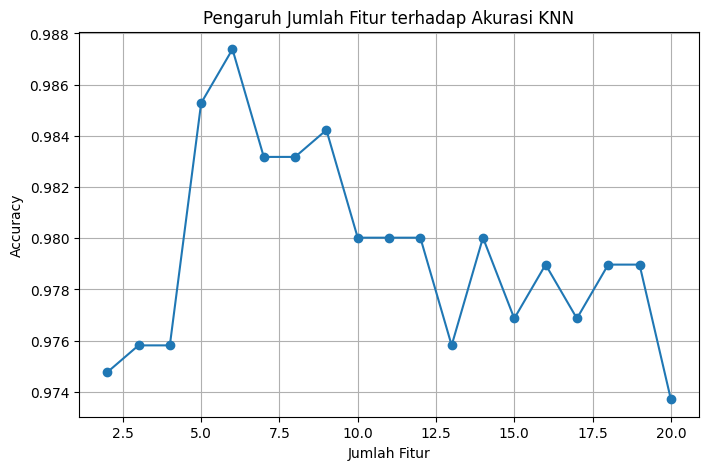

In [42]:
# Grafik Analisis Jumlah Fitur
import matplotlib.pyplot as plt


fitur = [x[0] for x in hasil]
akurasi = [x[1] for x in hasil]


plt.figure(figsize=(8,5))

plt.plot(
    fitur,
    akurasi,
    marker="o"
)

plt.xlabel(
    "Jumlah Fitur"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Pengaruh Jumlah Fitur terhadap Akurasi KNN"
)

plt.grid()

plt.show()

Interpretasi grafik:

* Akurasi meningkat ketika fitur informatif ditambahkan.
* Setelah sekitar 6 fitur, peningkatan performa tidak signifikan.
* Penggunaan seluruh fitur tidak selalu menghasilkan performa terbaik karena beberapa fitur dapat membawa noise.

3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai
k
k yang terbaik? Lampirkan grafika analisis dan alasan Anda.

In [43]:
# Setelah fitur terbaik diperoleh:
# sd, Q25, IQR, sp.ent, sfm, meanfun
# dilakukan percobaan nilai: k = 1 sampai 20
# Kode analisis nilai k
selector = SelectKBest(
    f_classif,
    k=6
)


X_train_best = selector.fit_transform(
    X_train,
    y_train
)

X_test_best = selector.transform(
    X_test
)



train_acc=[]
test_acc=[]


for k in range(1,21):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_best,
        y_train
    )


    train_acc.append(
        accuracy_score(
            y_train,
            model.predict(X_train_best)
        )
    )


    test_acc.append(
        accuracy_score(
            y_test,
            model.predict(X_test_best)
        )
    )

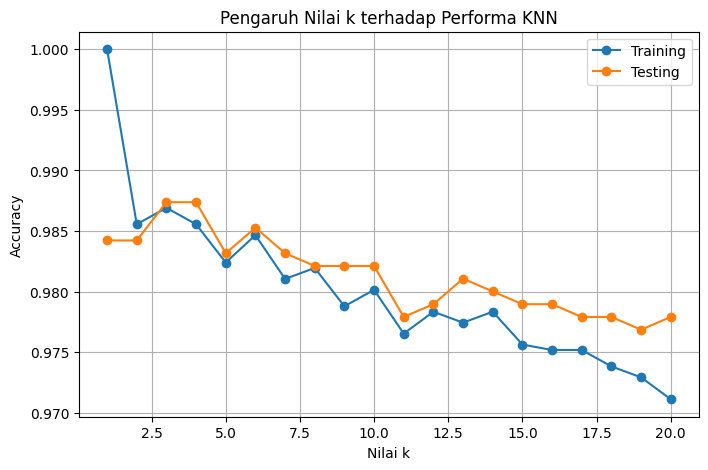

In [44]:
# Grafik nilai k
plt.figure(figsize=(8,5))


plt.plot(
    range(1,21),
    train_acc,
    marker="o",
    label="Training"
)


plt.plot(
    range(1,21),
    test_acc,
    marker="o",
    label="Testing"
)


plt.xlabel("Nilai k")

plt.ylabel("Accuracy")

plt.title(
    "Pengaruh Nilai k terhadap Performa KNN"
)

plt.legend()

plt.grid()

plt.show()

Hasil analisis nilai k
| k | Training Accuracy | Testing Accuracy |
|---|-------------------|------------------|
| 1 | 100%              | 98.42%           |
| 2 | 98.55%            | 98.42%           |
| **3** | **98.69%**    | **98.74%**       |
| 4 | 98.55%            | 98.74%           |
| 5 | 98.24%            | 98.31%           |
| 10 | 98.01%           | 98.21%           |

Nilai k terbaik

Berdasarkan hasil percobaan: k = 3
Karena:
1. Memiliki akurasi testing tertinggi: Accuracy = 98.74%
2. Tidak mengalami overfitting seperti k=1.

Pada: k = 1
training accuracy = 100%

tetapi testing lebih rendah.

Hal tersebut menunjukkan model terlalu mengikuti data training.

Sedangkan: k = 3

memberikan keseimbangan antara:

* kemampuan mengenali pola training
* kemampuan generalisasi terhadap data baru